In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("../../01_data/processed/dataforge_cleaned.csv")

os.makedirs("../outputs/plots", exist_ok=True)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Sales Category,Sales Range
0,1,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017.0,August,Low,Medium
1,2,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017.0,August,High,High
2,3,CA-2017-138688,2017-12-06,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017.0,December,Low,Low
3,4,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016.0,November,High,High
4,5,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016.0,November,Low,Low


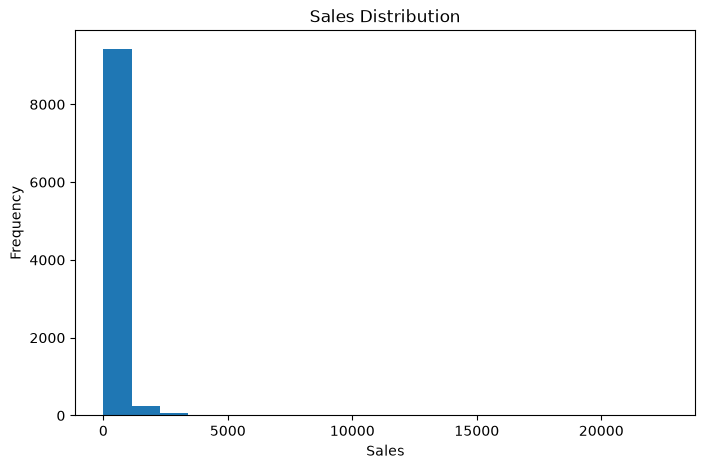

In [2]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.savefig("../outputs/plots/histogram_sales.png")
plt.show()

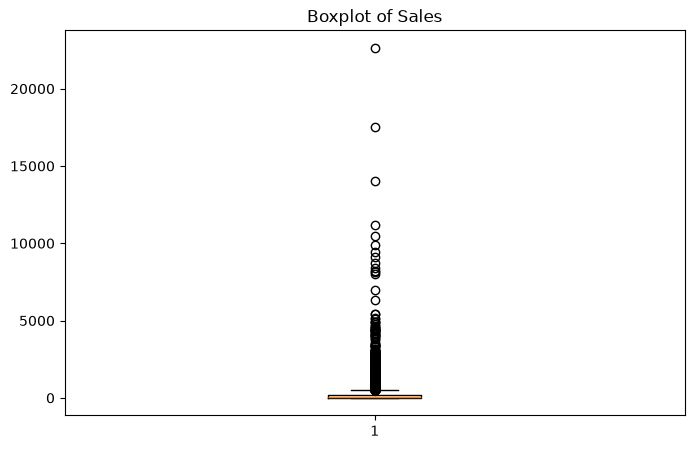

In [3]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Sales"])
plt.title("Boxplot of Sales")
plt.savefig("../outputs/plots/boxplot_sales.png")
plt.show()

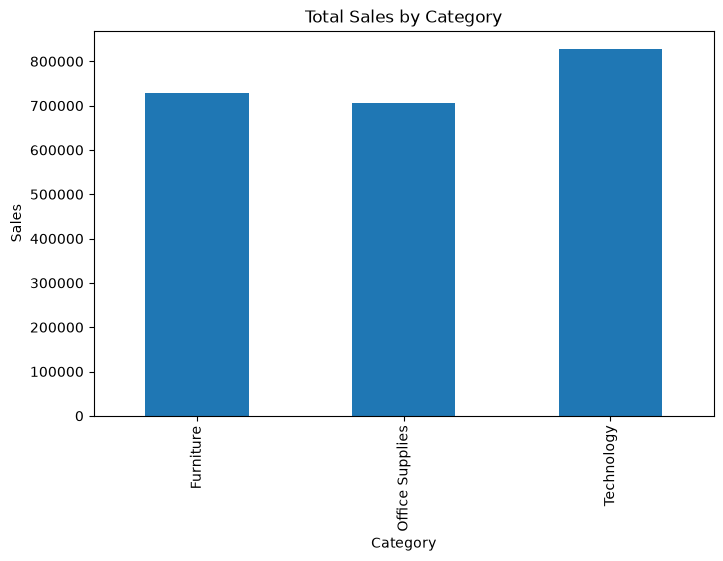

In [4]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.savefig("../outputs/plots/bar_category.png")
plt.show()

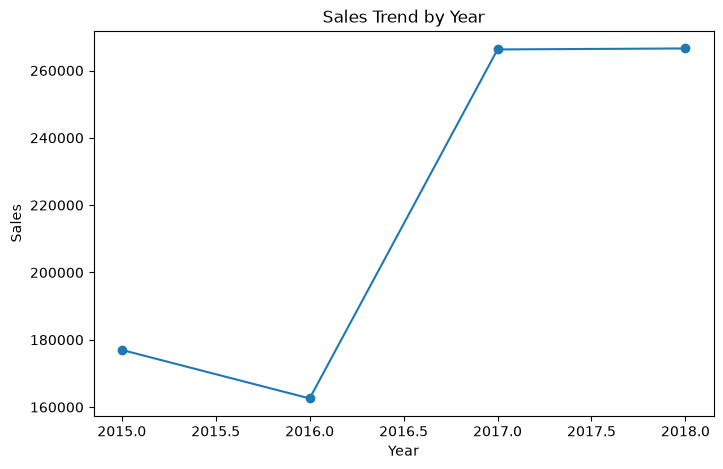

In [5]:
year_sales = df.groupby("Order Year")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.plot(year_sales.index, year_sales.values, marker="o")
plt.title("Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.savefig("../outputs/plots/line_sales.png")
plt.show()

In [7]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Order Year', 'Order Month', 'Sales Category', 'Sales Range']


In [9]:
print(df["Order Month"].dtype)
print(df["Order Month"].head())

str
0      August
1      August
2    December
3    November
4    November
Name: Order Month, dtype: str


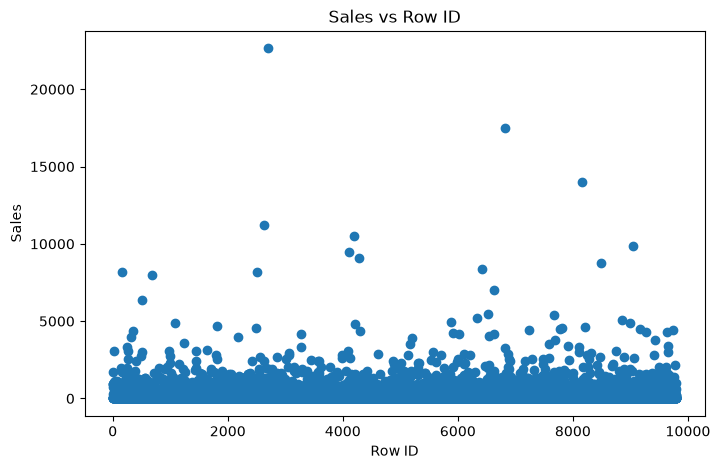

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(df["Row ID"], df["Sales"])

plt.title("Sales vs Row ID")
plt.xlabel("Row ID")
plt.ylabel("Sales")

plt.savefig("../outputs/plots/scatter_sales.png")

plt.show()

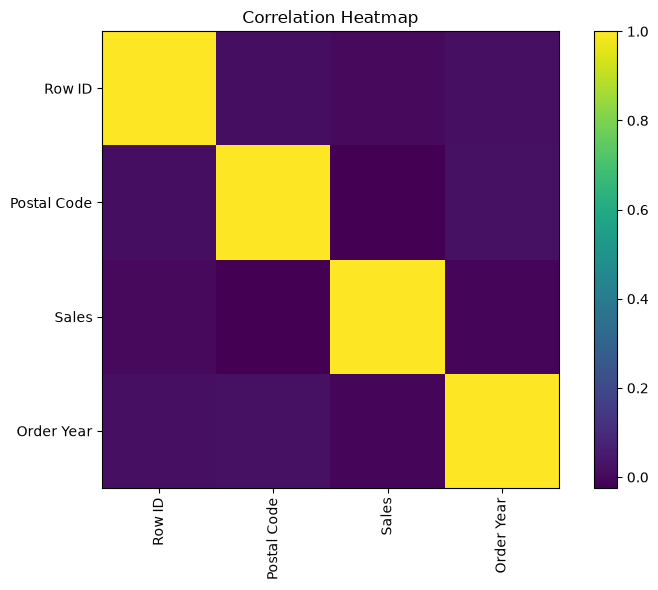

In [11]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("../outputs/plots/correlation_heatmap.png")

plt.show()

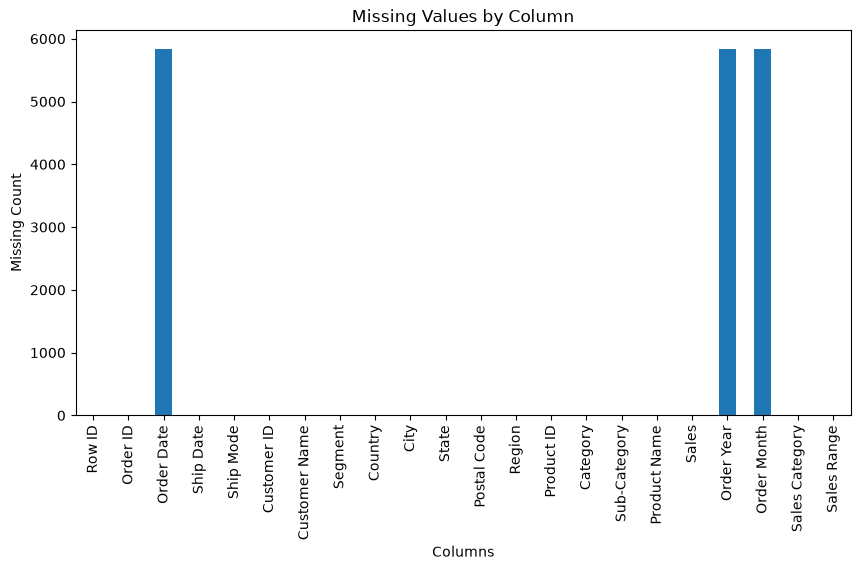

In [12]:
missing = df.isnull().sum()

plt.figure(figsize=(10,5))

missing.plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")

plt.savefig("../outputs/plots/missing_values.png")

plt.show()

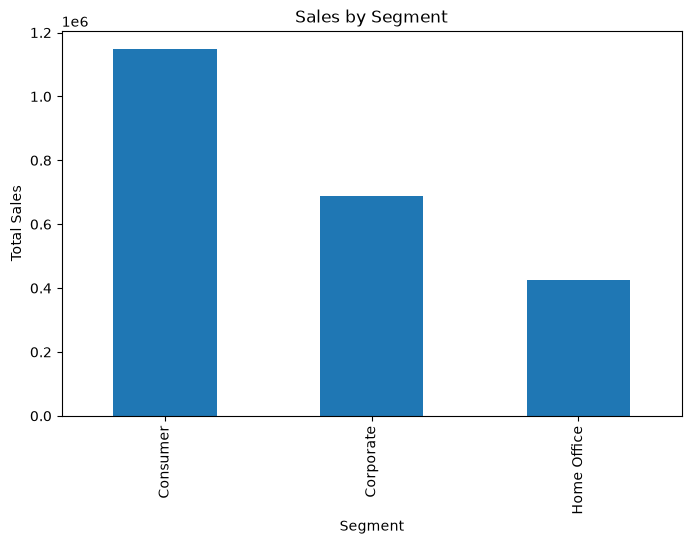

In [13]:
segment_sales = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.savefig("../outputs/plots/grouped_segment.png")

plt.show()